<a href="https://colab.research.google.com/github/suryaph971/Langchain/blob/main/LangChain_Google_Gemini_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 17.9 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [ ]:
pip install -q langchain_google_genai

In [5]:
pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 786.8/786.8 kB 17.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 69.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 101.5 MB/s  0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 25.0
    Uninstalling packaging-25.0:
      Successfully uninstalled packaging-25.0
  Attempting uninstall: openai
    Found existing installation: openai 1.99.8
    Uninstalling openai-1.99.8:
      Successfully uninstalled openai-1.99.8
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22/22 [langchain-cohere]


In [7]:
from dotenv import load_dotenv,find_dotenv
load_dotenv(find_dotenv(),override=True)

True

In [8]:
import getpass
import os
if 'GOOGLE_API_KEY' not in os.environ:
    os.environ['GOOGLE_API_KEY'] = getpass.getpass('Enter your Google API Key: ')

In [10]:
import google.generativeai as genai
for model in genai.list_models():
    print(model.name)

models/embedding-gecko-001
models/gemini-1.5-pro-latest
models/gemini-1.5-pro-002
models/gemini-1.5-pro
models/gemini-1.5-flash-latest
models/gemini-1.5-flash
models/gemini-1.5-flash-002
models/gemini-1.5-flash-8b
models/gemini-1.5-flash-8b-001
models/gemini-1.5-flash-8b-latest
models/gemini-2.5-pro-preview-03-25
models/gemini-2.5-flash-preview-05-20
models/gemini-2.5-flash
models/gemini-2.5-flash-lite-preview-06-17
models/gemini-2.5-pro-preview-05-06
models/gemini-2.5-pro-preview-06-05
models/gemini-2.5-pro
models/gemini-2.0-flash-exp
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-exp-image-generation
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.0-flash-preview-image-generation
models/gemini-2.0-flash-lite-preview-02-05
models/gemini-2.0-flash-lite-preview
models/gemini-2.0-pro-exp
models/gemini-2.0-pro-exp-02-05
models/gemini-exp-1206
models/gemini-2.0-flash-thinking-exp-01-21
models/gemini-2.0-flash-thinking-exp
models/ge

#Integrating Gemini with LangChain

In [12]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model='gemini-1.5-flash',temperature=0.9)
response = llm.invoke("Write about Data Engineers work in 2030?")
print(response.content)


The Data Engineer role in 2030 will be significantly transformed from its current iteration.  While the core responsibilities of building, maintaining, and optimizing data pipelines will remain, the tools, technologies, and the very nature of the data itself will undergo a dramatic shift.  Here's a glimpse into the potential landscape:

**1.  The Rise of AI-Assisted Data Engineering:**

* **Automated Pipeline Construction:**  AI will play a much larger role in automating the creation and management of data pipelines.  Tools will be able to suggest optimal architectures, automatically generate code, and even self-heal pipelines based on detected anomalies.  Data engineers will focus more on defining the business requirements and overseeing the AI's work, rather than writing extensive code manually.
* **Intelligent Data Discovery and Profiling:**  AI-powered tools will automatically discover, classify, and profile data across diverse sources, simplifying the process of understanding data

In [13]:
from langchain.prompts import PromptTemplate
from langchain.chains import LLMChain
llm = ChatGoogleGenerativeAI(model='gemini-1.5-flash')
prompt = PromptTemplate.from_template("You are a content creator. Write me a tweet about {topic}")

chain = prompt | llm

topic = "Why will AI change the world"
response = chain.invoke(input = topic)
print(response)

content="AI isn't just a tech trend; it's a world-changer.  From revolutionizing healthcare & manufacturing to tackling climate change & personalizing education, AI's potential is limitless.  Get ready for a future shaped by intelligent machines! #AI #ArtificialIntelligence #FutureofTech #Innovation" additional_kwargs={} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-1.5-flash', 'safety_ratings': []} id='run--20880d56-7487-4796-8c6a-281741f0ca5b-0' usage_metadata={'input_tokens': 17, 'output_tokens': 63, 'total_tokens': 80, 'input_token_details': {'cache_read': 0}}


In [14]:
print(response.content)
print()
print(response.response_metadata)
print()
print(response.usage_metadata)

AI isn't just a tech trend; it's a world-changer.  From revolutionizing healthcare & manufacturing to tackling climate change & personalizing education, AI's potential is limitless.  Get ready for a future shaped by intelligent machines! #AI #ArtificialIntelligence #FutureofTech #Innovation

{'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-1.5-flash', 'safety_ratings': []}

{'input_tokens': 17, 'output_tokens': 63, 'total_tokens': 80, 'input_token_details': {'cache_read': 0}}


#System Prompt and Streaming

In [15]:
from langchain_core.messages import HumanMessage,SystemMessage
llm = ChatGoogleGenerativeAI(model='gemini-1.5-flash')

output = llm.invoke(
    [
        SystemMessage(content="Answer only YES or NO in telugu"),
        HumanMessage(content="Is AI a human being?")
    ]
)

output.content

'లేదు'

#Multimodal AI With Gemini

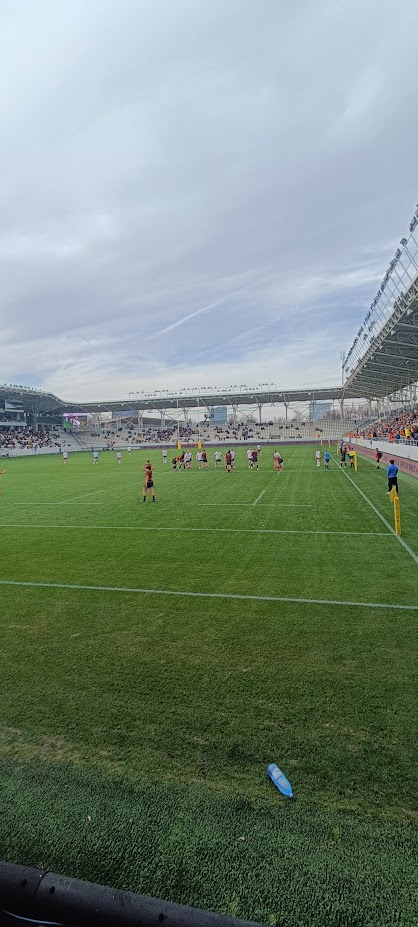

In [16]:
from IPython.display import Image,display
display(Image(filename='match.jpg'))

In [18]:
import base64
def encode_image(image_path):
    with open(image_path,'rb') as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

byte_image = encode_image('match.jpg')

In [20]:
from langchain_core.messages import HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI

lm = ChatGoogleGenerativeAI(model='gemini-1.5-flash', temperature=0.2)

prompt = 'What is in this image?'


message = HumanMessage(
    content=[
        {
            'type':'text',
            'text':prompt
        },
        {
            'type':'image_url',
            'image_url':{'url':f'data:image/jpeg;base64,{byte_image}'}
        }
    ]
)

response = llm.invoke([message])

In [21]:
print(response.content)

That's a photo taken from the stands of a rugby match.  The image shows a rugby game in progress on a well-maintained grass field.  The stadium is modern with a large covered seating area, and there are spectators in the stands.  The sky is overcast.  A discarded blue plastic bottle is visible on the grass near the bottom of the image.


In [26]:
def ask_gemini(prompt, image_path, model='gemini-1.5-flash'):
    byte_image = encode_image(image_path)
    llm = ChatGoogleGenerativeAI(model=model)
    message = HumanMessage(
    content=[
        {
            'type': 'text',
            'text': prompt
        },
        {
            'type': 'image_url',
            'image_url': {'url': f'data:image/jpeg;base64,{byte_image}'}
        }
    ]
    )
    response = llm.invoke([message])
    return response


In [27]:
response = ask_gemini('What is this sport?', 'match.jpg')
print(response.content)

That's rugby union.  The scrum, the shape of the field, and the number of players are all consistent with rugby union rules.


In [28]:
response = ask_gemini('How many players can you identify in each team?', 'match.jpg')
print(response.content)

Here's the count of players I can identify in each team:

* **Team in darker jerseys (maroon/burgundy):**  At least 13 players are clearly visible in a group near the center of the field. There may be more players partially obscured or further away.

* **Team in lighter jerseys (white/light gray):** At least 12 players are visible grouped together near the center of the field. There may be more players partially hidden or further away.

It's difficult to give an exact number because some players are partially obscured or too far away to be confidently identified.  A rugby team typically has 13-15 players on the field at a time.


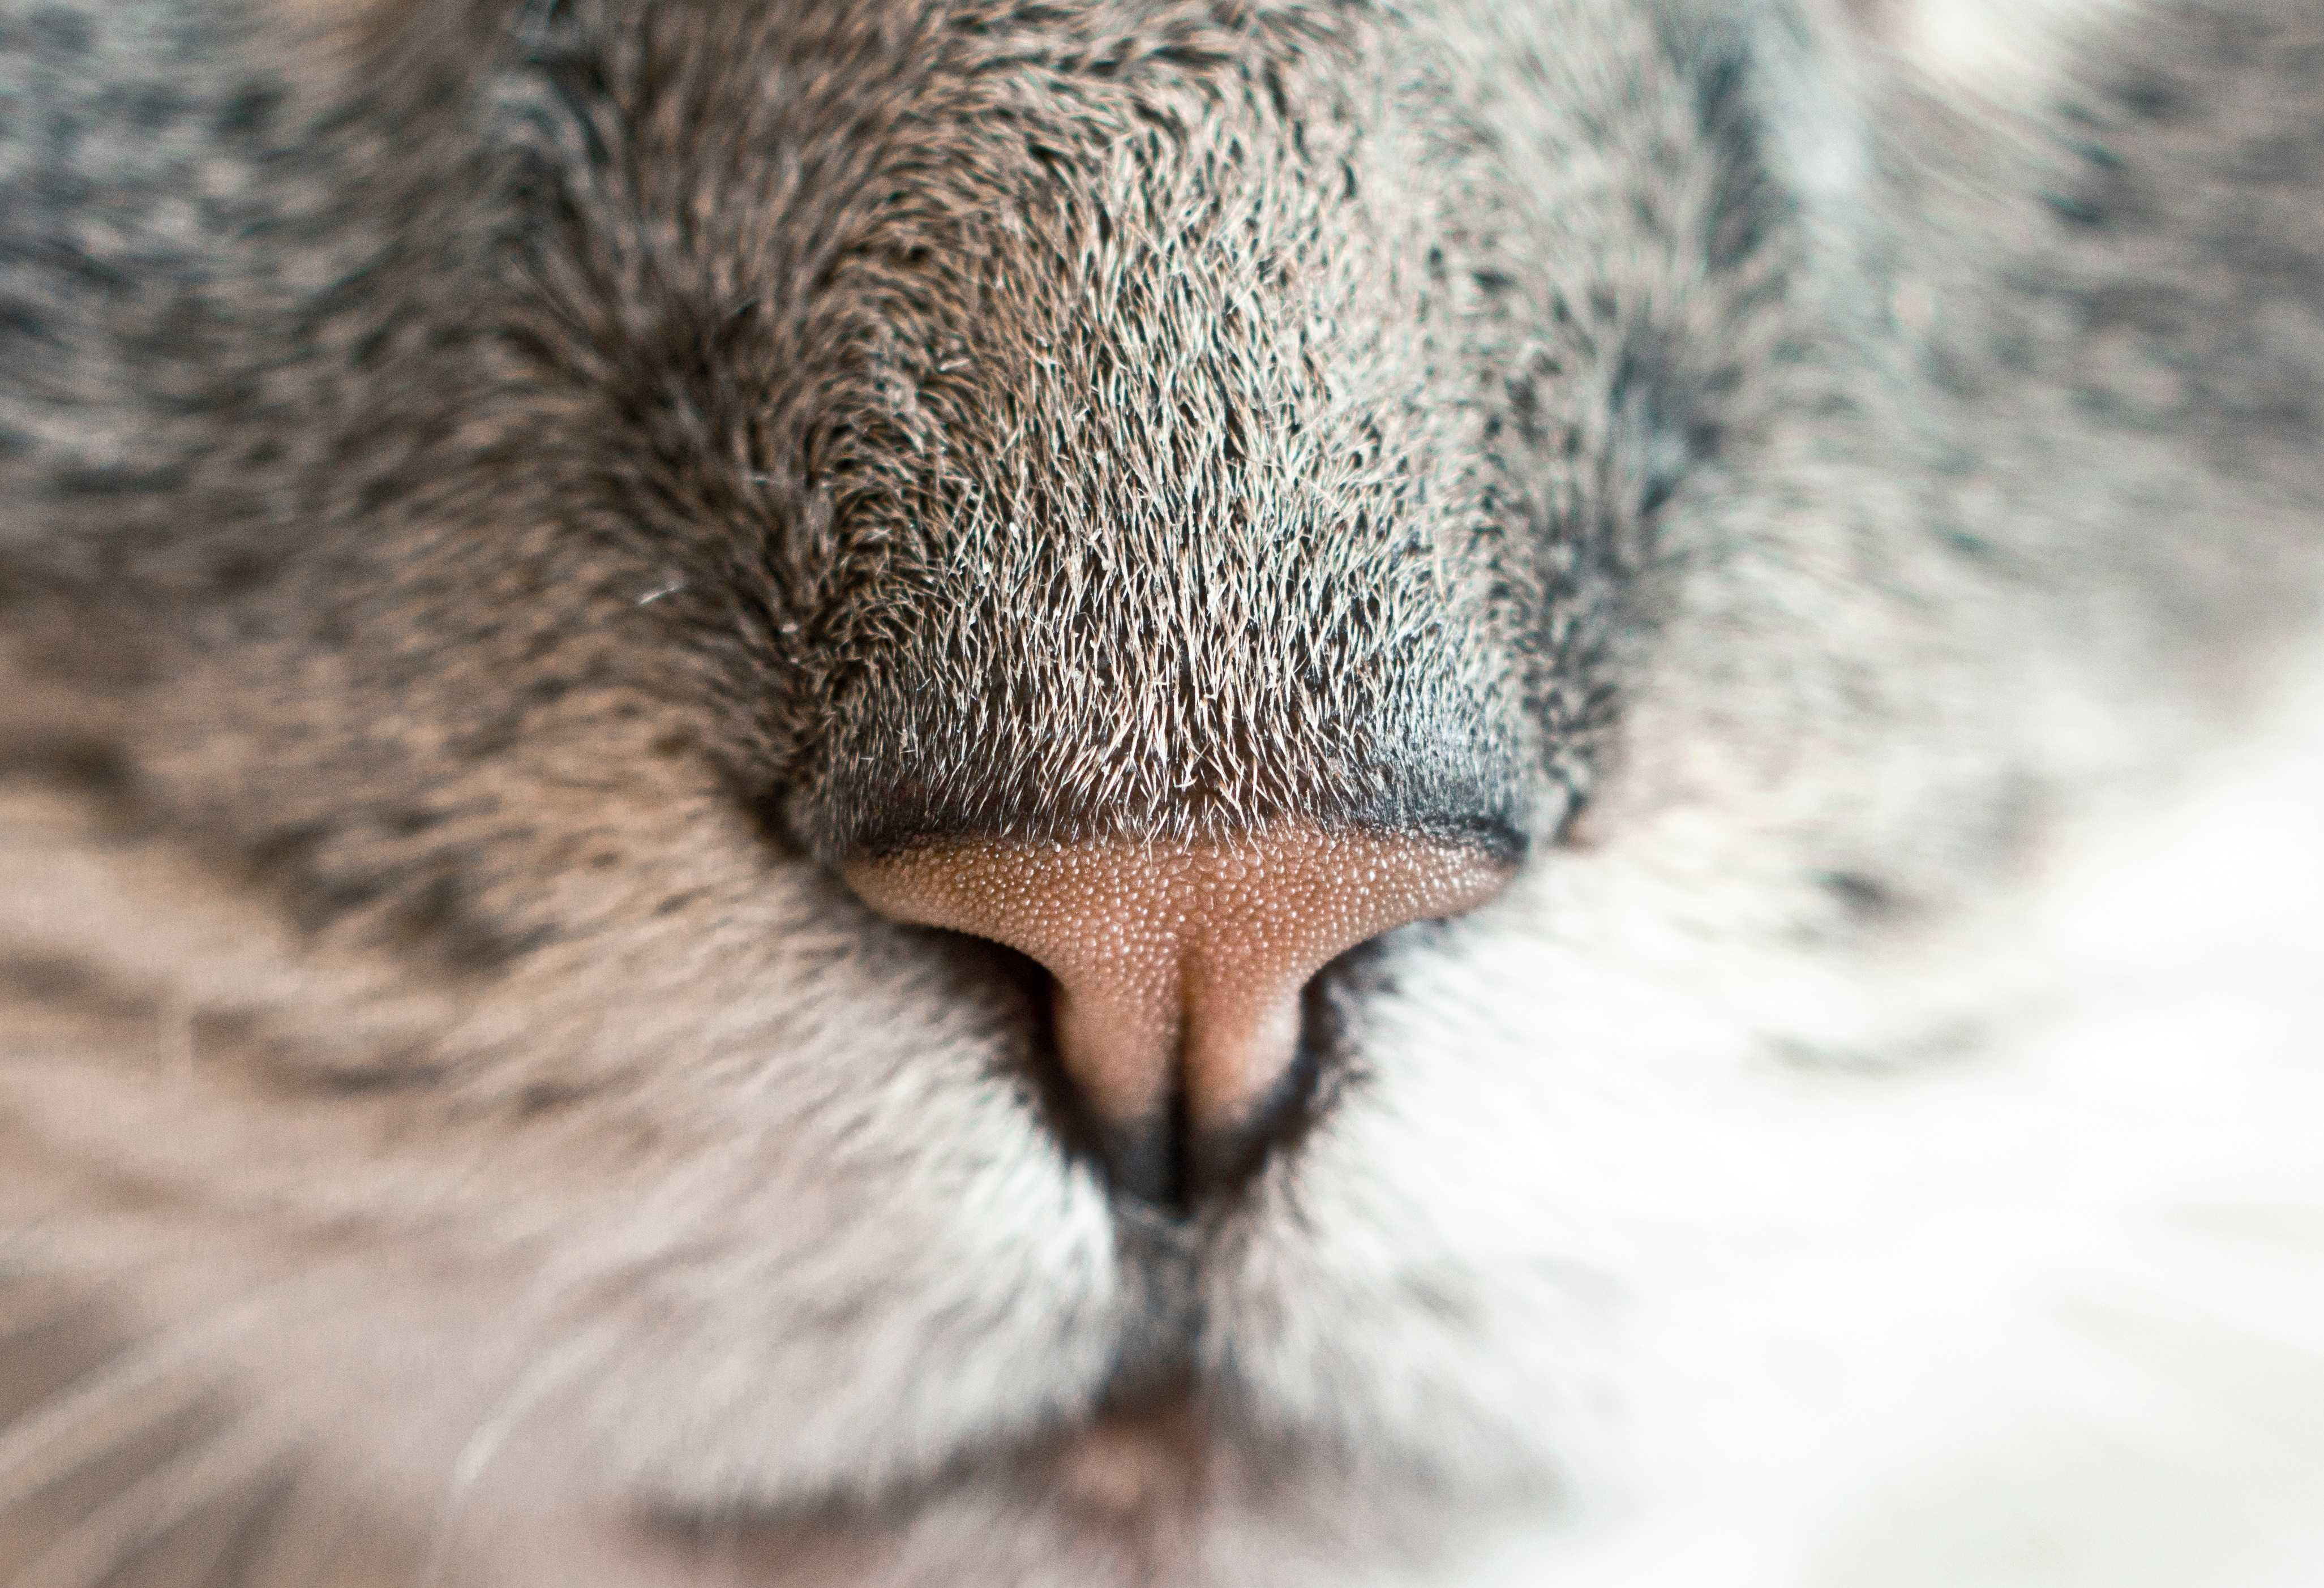

In [29]:
import requests
image_url = 'https://picsum.photos/id/40/4106/2806'
content = requests.get(image_url).content

with open('online_image.jpg','wb') as file:
    file.write(content)
display(Image(filename='online_image.jpg'))

In [30]:
response = ask_gemini('Describe this image in detail','online_image.jpg')
print(response.content)

Here's a description of the image:

The image is a close-up, macro shot of a cat's nose and the surrounding fur. 


The focus is sharply on the cat's nose, which is a pinkish-brown color and textured with numerous tiny, visible pores. The nostrils are dark and slightly visible.  The fur immediately surrounding the nose is a darker gray, almost black in places, and appears dense and slightly coarse.  The hairs are individually discernible. As the image moves away from the nose, the fur becomes lighter, transitioning to a much lighter gray or off-white, with the fur becoming increasingly out of focus. The overall color palette is muted, consisting primarily of shades of gray and brown, with the pink of the nose being the most vibrant color. The lighting is soft and diffused, preventing harsh shadows. The overall impression is one of softness and detail, focusing attention on the texture of the cat's nose and fur.
